In [5]:
import os
print(os.listdir('/content/'))

['.config', 'Churn_Modelling.csv', 'sample_data']


In [6]:

!pip install scikit-learn pandas numpy matplotlib seaborn xgboost


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import xgboost as xgb

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [7]:

df = pd.read_csv('Churn_Modelling.csv')


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  


Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


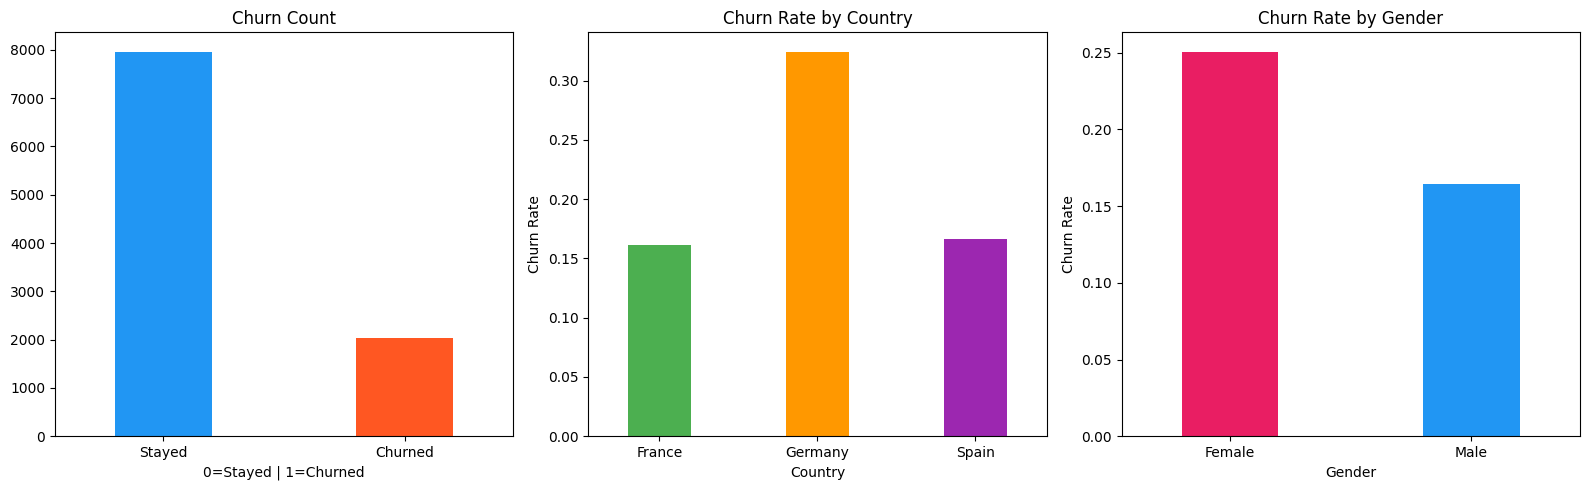

In [8]:
# Check churn distribution
print("Churn Distribution:")
print(df['Exited'].value_counts())
print("\nChurn Percentage:")
print(df['Exited'].value_counts(normalize=True)*100)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Churn count
df['Exited'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2196F3','#FF5722'],
    width=0.4
)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('0=Stayed | 1=Churned')
axes[0].set_xticklabels(['Stayed','Churned'], rotation=0)

# Churn by Geography
df.groupby('Geography')['Exited'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#4CAF50','#FF9800','#9C27B0'],
    width=0.4
)
axes[1].set_title('Churn Rate by Country')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=0)

# Churn by Gender
df.groupby('Gender')['Exited'].mean().plot(
    kind='bar', ax=axes[2],
    color=['#E91E63','#2196F3'],
    width=0.4
)
axes[2].set_title('Churn Rate by Gender')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Churn Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Columns after dropping useless ones:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Geography
df['Geography'] = le.fit_transform(df['Geography'])

print("\nAfter Encoding:")
print(df[['Gender','Geography']].head())
print("\nData types now:")
print(df.dtypes)

Columns after dropping useless ones:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

After Encoding:
   Gender  Geography
0       0          0
1       0          2
2       0          0
3       0          0
4       0          2

Data types now:
CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [10]:
# Separate features and target
X = df.drop('Exited', axis=1)  # all columns except Exited
y = df['Exited']                # only Exited column

print("Features (X) shape:", X.shape)
print("Target (y) shape  :", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Data ready for training!")

Features (X) shape: (10000, 10)
Target (y) shape  : (10000,)

Features used:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Training samples  : 8000
Testing samples   : 2000

✅ Data ready for training!


In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, preds)
    results[name] = {'accuracy': acc, 'roc': roc}
    print(f"✅ Accuracy : {acc:.4f}")
    print(f"   ROC AUC : {roc:.4f}\n")

best_name = max(results, key=lambda x: results[x]['roc'])
print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy : {results[best_name]['accuracy']:.4f}")
print(f"   ROC AUC  : {results[best_name]['roc']:.4f}")

Training Logistic Regression...
✅ Accuracy : 0.7065
   ROC AUC : 0.6982

Training Random Forest...
✅ Accuracy : 0.8645
   ROC AUC : 0.7004

Training Gradient Boosting...
✅ Accuracy : 0.8635
   ROC AUC : 0.7161

🏆 Best Model: Gradient Boosting
   Accuracy : 0.8635
   ROC AUC  : 0.7161


Training XGBoost...
✅ XGBoost Accuracy : 0.8255
   XGBoost ROC AUC : 0.7953

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.85      0.89      1607
     Churned       0.54      0.75      0.63       393

    accuracy                           0.83      2000
   macro avg       0.74      0.80      0.76      2000
weighted avg       0.85      0.83      0.84      2000



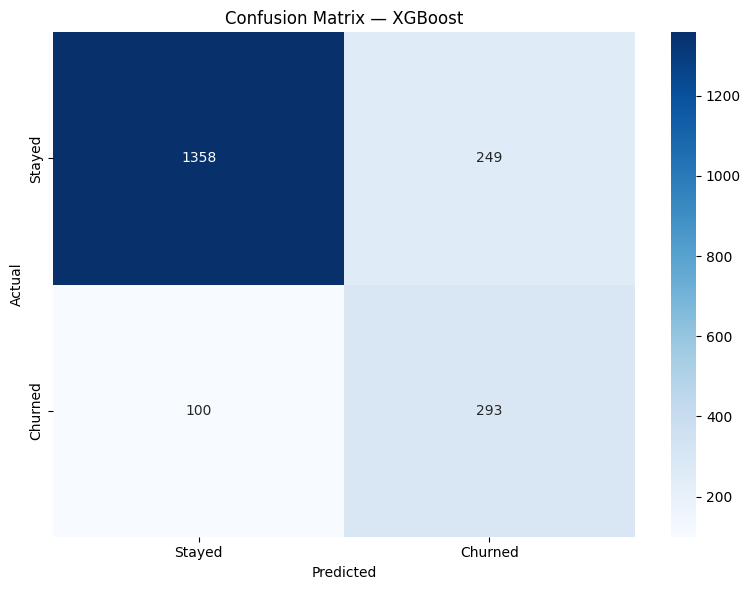

In [12]:
# Train
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,    # handles imbalance (79/20 ratio)
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

acc = accuracy_score(y_test, xgb_preds)
roc = roc_auc_score(y_test, xgb_preds)

print(f"✅ XGBoost Accuracy : {acc:.4f}")
print(f"   XGBoost ROC AUC : {roc:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['Stayed','Churned']))

# Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'],
            cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

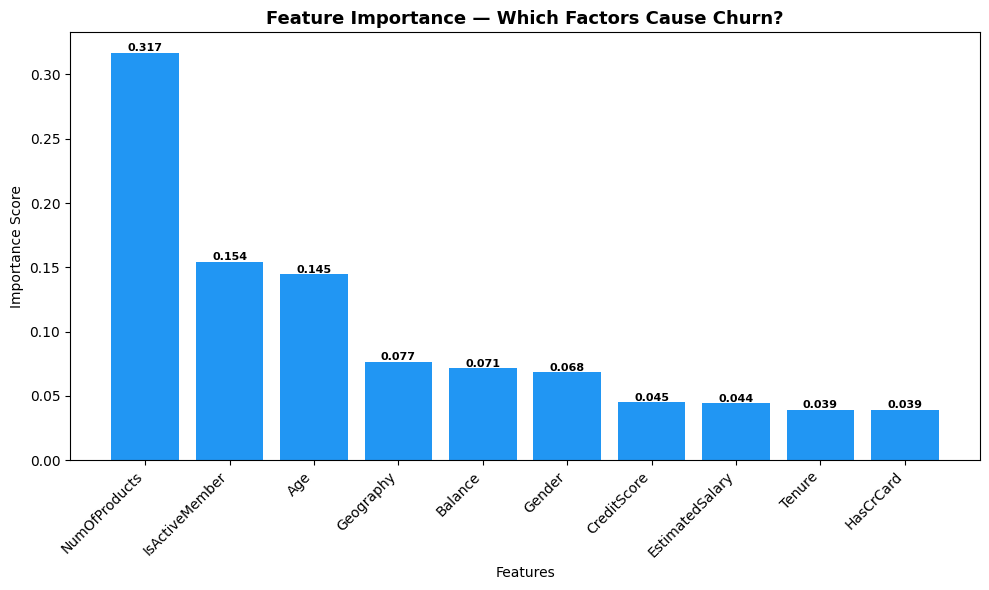


Top 5 Churn Factors:
1. NumOfProducts — 0.3169
2. IsActiveMember — 0.1544
3. Age — 0.1446
4. Geography — 0.0765
5. Balance — 0.0714


In [13]:

feature_names = X.columns.tolist()
importances = xgb_model.feature_importances_


indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
bars = plt.bar(range(len(feature_names)),
               importances[indices],
               color='#2196F3')

plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')


for bar, val in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.3f}',
             ha='center', fontsize=8, fontweight='bold')

plt.title('Feature Importance — Which Factors Cause Churn?',
          fontweight='bold', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Churn Factors:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} — {importances[indices[i]]:.4f}")

In [14]:
def predict_churn(credit_score, geography, gender,
                  age, tenure, balance, num_products,
                  has_crcard, is_active, salary):

    # geography
    geo_map = {'France':0, 'Germany':1, 'Spain':2}
    gen_map = {'Female':0, 'Male':1}

    customer = np.array([[
        credit_score,
        geo_map[geography],
        gen_map[gender],
        age, tenure, balance,
        num_products, has_crcard,
        is_active, salary
    ]])

    # Scale
    customer_scaled = scaler.transform(customer)

    # Predict
    prediction = xgb_model.predict(customer_scaled)[0]
    probability = xgb_model.predict_proba(customer_scaled)[0]

    print(f"Credit Score  : {credit_score}")
    print(f"Geography     : {geography}")
    print(f"Gender        : {gender}")
    print(f"Age           : {age}")
    print(f"Tenure        : {tenure} years")
    print(f"Balance       : ${balance:,.2f}")
    print(f"Products      : {num_products}")
    print(f"Active Member : {'Yes' if is_active else 'No'}")
    print(f"Salary        : ${salary:,.2f}")
    print(f"\nStay %    : {probability[0]*100:.2f}%")
    print(f"Churn %   : {probability[1]*100:.2f}%")

    if prediction == 1:
        print("🚨 RESULT: CUSTOMER WILL CHURN!")
        print("→ Action: Send retention offer immediately!")
    else:
        print("✅ RESULT: CUSTOMER WILL STAY!")
    print("-"*50)

# Test customers
print("="*50)
print("CUSTOMER CHURN PREDICTION SYSTEM")
print("="*50)


print("\nTest 1 — Young active customer:")
predict_churn(700, 'France', 'Male',
              30, 5, 50000, 2, 1, 1, 60000)


print("\nTest 2 — Old inactive German customer:")
predict_churn(400, 'Germany', 'Female',
              55, 1, 150000, 1, 0, 0, 80000)


print("\nTest 3 — Middle aged Spanish customer:")
predict_churn(600, 'Spain', 'Male',
              45, 3, 0, 2, 1, 0, 100000)


print("\nTest 4 — High risk customer:")
predict_churn(350, 'Germany', 'Female',
              60, 1, 200000, 1, 0, 0, 120000)

CUSTOMER CHURN PREDICTION SYSTEM

Test 1 — Young active customer:
Credit Score  : 700
Geography     : France
Gender        : Male
Age           : 30
Tenure        : 5 years
Balance       : $50,000.00
Products      : 2
Active Member : Yes
Salary        : $60,000.00

Stay %    : 94.91%
Churn %   : 5.09%
✅ RESULT: CUSTOMER WILL STAY!
--------------------------------------------------

Test 2 — Old inactive German customer:
Credit Score  : 400
Geography     : Germany
Gender        : Female
Age           : 55
Tenure        : 1 years
Balance       : $150,000.00
Products      : 1
Active Member : No
Salary        : $80,000.00

Stay %    : 2.92%
Churn %   : 97.08%
🚨 RESULT: CUSTOMER WILL CHURN!
→ Action: Send retention offer immediately!
--------------------------------------------------

Test 3 — Middle aged Spanish customer:
Credit Score  : 600
Geography     : Spain
Gender        : Male
Age           : 45
Tenure        : 3 years
Balance       : $0.00
Products      : 2
Active Member : No
Salar

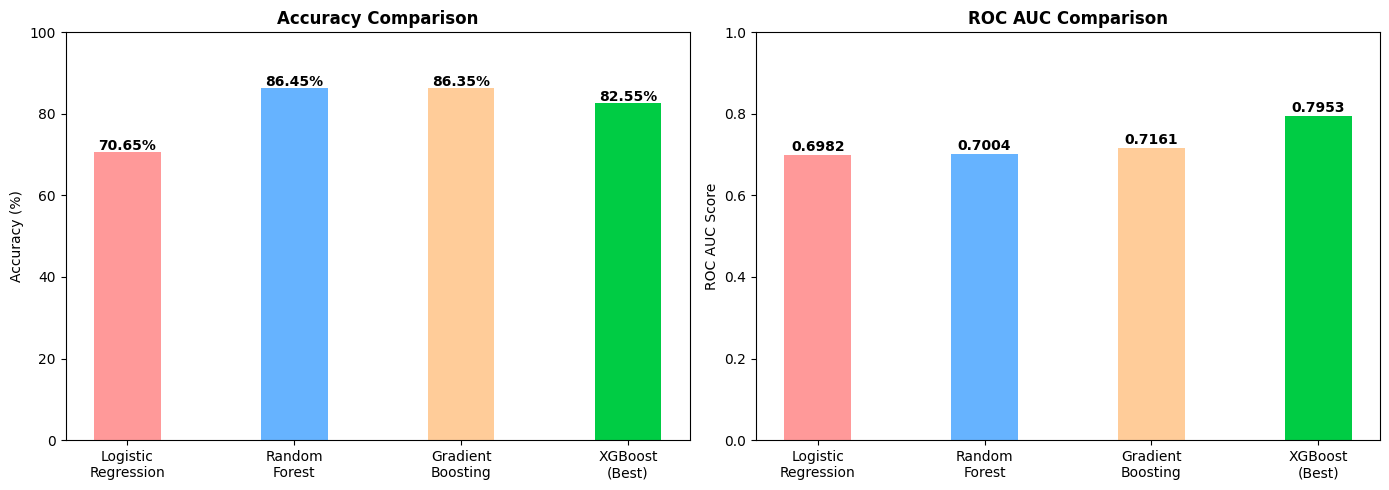


✅ TASK 3 COMPLETE!
Dataset         : 10,000 customers
Features        : 10
Best Model      : XGBoost
Accuracy        : 82.55%
ROC AUC         : 0.7953
Churn Recall    : 75%

Top Churn Factors:
1. NumOfProducts  — 31.69%
2. IsActiveMember — 15.44%
3. Age            — 14.46%
4. Geography      — 7.65%
5. Balance        — 7.14%


In [15]:
# comparison
model_names  = ['Logistic\nRegression',
                'Random\nForest',
                'Gradient\nBoosting',
                'XGBoost\n(Best)']
accuracies   = [0.7065, 0.8645, 0.8635, 0.8255]
roc_scores   = [0.6982, 0.7004, 0.7161, 0.7953]
colors       = ['#ff9999','#66b3ff','#ffcc99','#00cc44']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Accuracy comparison
bars1 = ax1.bar(model_names,
                [a*100 for a in accuracies],
                color=colors, width=0.4)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.2f}%',
             ha='center', fontweight='bold')

# ROC AUC comparison
bars2 = ax2.bar(model_names,
                roc_scores,
                color=colors, width=0.4)
ax2.set_title('ROC AUC Comparison', fontweight='bold')
ax2.set_ylabel('ROC AUC Score')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, roc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ TASK 3 COMPLETE!")
print("="*45)
print(f"Dataset         : 10,000 customers")
print(f"Features        : 10")
print(f"Best Model      : XGBoost")
print(f"Accuracy        : 82.55%")
print(f"ROC AUC         : 0.7953")
print(f"Churn Recall    : 75%")
print(f"\nTop Churn Factors:")
print(f"1. NumOfProducts  — 31.69%")
print(f"2. IsActiveMember — 15.44%")
print(f"3. Age            — 14.46%")
print(f"4. Geography      — 7.65%")
print(f"5. Balance        — 7.14%")

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1 Score:", f1_score(y_test, xgb_preds))

Precision: 0.540590405904059
Recall: 0.7455470737913485
F1 Score: 0.6267379679144385
